In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# CFU data
WT_CFU = [64]
FO_CFU = [17]

WT_CFU_20250401 = [48, 80, 49, 82, 65]
FO_CFU_20250401 = [7, 11, 11, 21, 10]

# combine
WT_CFU = WT_CFU + WT_CFU_20250401
FO_CFU = FO_CFU + FO_CFU_20250401

wt = np.array(WT_CFU)
fo = np.array(FO_CFU)

# mead, std, median
print(f"WT CFU: {np.mean(wt):.2f} ± {np.std(wt):.2f} (median: {np.median(wt)})")
print(f"FO CFU: {np.mean(fo):.2f} ± {np.std(fo):.2f} (median: {np.median(fo)})")

WT CFU: 64.67 ± 13.29 (median: 64.5)
FO CFU: 12.83 ± 4.71 (median: 11.0)


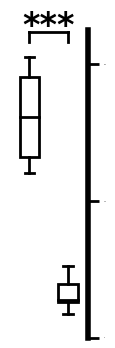

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# -- Line thickness settings --
thickness_tick = 2
thickness_axis = 4
thickness_box = 2
thickness_median = 2
thickness_test = 2
length_tick = 8

# -- font settings --
font_tick_label = 0
font_test = 24
shift_test_line = -5
shift_test = -10


# Perform an independent two-sample t-test
t_stat, p_val = stats.ttest_ind(wt, fo)

# Define significance level markers
if p_val < 0.001:
    sig = '***'
elif p_val < 0.01:
    sig = '**'
elif p_val < 0.05:
    sig = '*'
else:
    sig = 'n.s.'  # not significant

# Box plot colors (minimal palette)
colors = ['white', 'white']

# Create figure
fig, ax = plt.subplots(figsize=(1, 4))

# Box plot with controlled line thickness
bp = ax.boxplot([wt, fo], patch_artist=True, widths=0.5, 
                medianprops={'color': 'black', 'linewidth': thickness_median},
                boxprops={'linewidth': thickness_box},
                whiskerprops={'linewidth': thickness_box},
                capprops={'linewidth': thickness_box})

# Set box colors
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Add significance annotation
y_max = max(max(wt), max(fo))
y_line = y_max * 1.15

ax.plot([1, 2], [y_line+shift_test_line, y_line+shift_test_line], color='black', linewidth=thickness_test)  # Horizontal line
ax.plot([1, 1], [y_line+shift_test_line, y_line * 0.97+shift_test_line], color='black', linewidth=thickness_test)  # Short vertical line (left)
ax.plot([2, 2], [y_line+shift_test_line, y_line * 0.97+shift_test_line], color='black', linewidth=thickness_test)  # Short vertical line (right)
ax.text(1.5, y_line * 1.02+shift_test, sig, ha='center', va='bottom', fontsize=font_test, fontweight='bold')

# Adjust y-axis
plt.ylim(0, 90)
plt.yticks([0, 40, 80])  # Three ticks
# plt.yticks([0, 100, 200])

# Parameters
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=font_tick_label, width=thickness_tick, length=length_tick)
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)
ax.set_title(ax.get_title(), fontsize=18)

# Remove unnecessary borders and elements
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(True)  # Keep the right y-axis spine
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Move y-axis to the right
ax.yaxis.tick_right()

# Remove x labels and ticks
ax.set_xticks([])
ax.set_xticklabels([])
ax.set_ylabel('')  # Remove y-label for minimalism

# axis thickness
ax.spines['right'].set_linewidth(thickness_axis)

# Save with high resolution, transparent background
# plt.savefig('CFU_comparison_boxplot_narrow.png', dpi=300, transparent=True, bbox_inches='tight')
